In [1]:

import pickle
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

# Load the detailed results file containing peak data for N=10^6
with open('detailed_results_N1e6.pkl', 'rb') as f:
 detailed_results = pickle.load(f)

# Inspect the structure of the loaded data
print("Keys in detailed_results:")
print(detailed_results.keys())
print("\n" + "="*80 + "\n")

# Check what's available for each function
for func_name in detailed_results.keys():
 print(f"\nFunction: {func_name}")
 print(f" Keys: {detailed_results[func_name].keys()}")
 if 'peaks' in detailed_results[func_name]:
 peaks_data = detailed_results[func_name]['peaks']
 print(f" Number of peaks: {len(peaks_data)}")
 if len(peaks_data) > 0:
 print(f" First peak keys: {peaks_data[0].keys()}")


Keys in detailed_results:
dict_keys(['zeta', 'f_rand', 'L_mobius'])



Function: zeta
 Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])

Function: f_rand
 Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])

Function: L_mobius
 Keys: dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])


In [2]:

# I see that the detailed_results contains the peak locations and r_values, 
# but I need to check if the S_k values are stored elsewhere or if I need to recompute them
# Let me check if there are omega decomposition data stored

# First, let's see if there are any other files in the directory
import os
print("Files in current directory:")
for f in os.listdir('.'):
 print(f" {f}")


Files in current directory:
 detailed_results_N1e6.pkl
 omega_values_N1e6.pkl
 .config
 .kernel_tmp


In [3]:

# The detailed_results file doesn't contain the S_k decomposition data directly.
# According to the task description, I need to recompute the ω-class sums at the peak locations.
# I have:
# 1. Peak locations (t values) for each function
# 2. Pre-computed Omega(n) values up to N=10^6
# 
# I need to:
# 1. Recompute the coefficients a_n for each function
# 2. At each peak t, compute S_k = Σ_{n: Ω(n)=k} a_n / n^{1/2+it}
# 3. Compute the contribution matrix C_jk = Re[S_j * conj(S_k)]

# First, load the omega values
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_array = pickle.load(f)

print(f"Omega array shape: {omega_array.shape}")
print(f"Omega array dtype: {omega_array.dtype}")
print(f"First 20 omega values: {omega_array[:20]}")
print(f"Max omega value: {omega_array.max()}")


Omega array shape: (1000000,)
Omega array dtype: int64
First 20 omega values: [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]
Max omega value: 19


In [4]:

# Good! The omega_array has values from index 0 to 999999, where omega_array[i] = Ω(i+1)
# Now I need to generate the coefficient arrays for f_rand and L_mobius

# Set the random seed for reproducibility
np.random.seed(42)

N = 1000000

# Generate f_rand coefficients (random ±1 multiplicative function)
# First, generate random values at primes
def is_prime(n):
 """Simple primality test"""
 if n < 2:
 return False
 if n == 2:
 return True
 if n % 2 == 0:
 return False
 for i in range(3, int(np.sqrt(n)) + 1, 2):
 if n % i == 0:
 return False
 return True

# Generate list of primes up to N using a sieve
def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit"""
 is_prime_arr = np.ones(limit + 1, dtype=bool)
 is_prime_arr[0] = is_prime_arr[1] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime_arr[i]:
 is_prime_arr[i*i:limit+1:i] = False
 return np.where(is_prime_arr)[0]

print("Generating primes up to N=10^6...")
primes = sieve_of_eratosthenes(N)
print(f"Number of primes up to {N}: {len(primes)}")
print(f"First 10 primes: {primes[:10]}")


Generating primes up to N=10^6...
Number of primes up to 1000000: 78498
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]


In [5]:

# Generate random ±1 values for f_rand at primes
# This needs to match the original generation with seed 42
print("Generating f_rand coefficients...")
f_rand_at_primes = np.random.choice([-1, 1], size=len(primes))
print(f"First 20 f_rand values at primes: {f_rand_at_primes[:20]}")

# Now extend multiplicatively to all n
# a_n = product of a_p^k for all prime powers p^k dividing n
def generate_multiplicative_function(N, primes, values_at_primes):
 """
 Generate a multiplicative function from its values at primes.
 Uses prime factorization approach.
 """
 a = np.zeros(N + 1, dtype=np.float64)
 a[1] = 1.0 # f(1) = 1 for multiplicative functions
 
 # Create a dictionary mapping primes to their values
 prime_vals = dict(zip(primes, values_at_primes))
 
 # For each n, compute a[n] multiplicatively
 for n in range(2, N + 1):
 # Factor n and compute product
 temp_n = n
 val = 1.0
 for p in primes:
 if p * p > temp_n:
 if temp_n > 1: # temp_n is prime
 if temp_n in prime_vals:
 val *= prime_vals[temp_n]
 else:
 val = 0.0 # Prime not in our list (shouldn't happen)
 break
 if temp_n % p == 0:
 power = 0
 while temp_n % p == 0:
 power += 1
 temp_n //= p
 val *= prime_vals[p] ** power
 a[n] = val
 
 return a[1:] # Return array indexed from 0 (representing a_1, a_2, ..., a_N)

print("Generating full f_rand array...")
a_f_rand = generate_multiplicative_function(N, primes, f_rand_at_primes)
print(f"f_rand array shape: {a_f_rand.shape}")
print(f"First 20 f_rand values: {a_f_rand[:20]}")
print(f"Non-zero fraction: {np.count_nonzero(a_f_rand) / len(a_f_rand):.4f}")


Generating f_rand coefficients...
First 20 f_rand values at primes: [-1 1 -1 -1 -1 1 -1 -1 -1 1 -1 -1 -1 -1 1 -1 1 1 1 -1]
Generating full f_rand array...


f_rand array shape: (1000000,)
First 20 f_rand values: [ 1. -1. 1. 1. -1. -1. -1. -1. 1. 1. -1. 1. 1. 1. -1. 1. -1. -1.
 -1. -1.]
Non-zero fraction: 1.0000


In [6]:

# Generate Möbius function coefficients
# μ(n) = 0 if n has a squared prime factor
# = 1 if n is a square-free product of an even number of primes
# = -1 if n is a square-free product of an odd number of primes

def generate_mobius(N, primes):
 """
 Generate Möbius function values for n = 1, 2, ..., N
 """
 mu = np.ones(N + 1, dtype=np.float64)
 mu[0] = 0
 
 # Use sieve-like approach
 for p in primes:
 # Mark multiples of p with alternating sign
 mu[p::p] *= -p
 
 # Mark multiples of p^2 as 0
 if p * p <= N:
 mu[p*p::p*p] = 0
 
 # Convert back: if mu[n] is still a product of primes, extract sign
 for n in range(1, N + 1):
 if mu[n] != 0:
 if abs(mu[n]) == n:
 mu[n] = mu[n] / n # Single prime, μ(p) = -1
 elif mu[n] < 0:
 mu[n] = 1.0 if abs(mu[n]) == n else -1.0
 else:
 mu[n] = 1.0 if mu[n] == n else 1.0
 
 return mu[1:]

# Actually, let me use a cleaner implementation
def generate_mobius_clean(N):
 """Generate Möbius function using standard algorithm"""
 mu = np.zeros(N + 1, dtype=np.int8)
 mu[1] = 1
 
 # Sieve approach
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark non-primes
 is_prime[p*2::p] = False
 
 # Update mu for multiples of p
 for k in range(p, N + 1, p):
 if mu[k] == 0:
 mu[k] = -1 if k == p else 0
 else:
 mu[k] *= -1
 
 # Set mu to 0 for multiples of p^2
 if p * p <= N:
 for k in range(p * p, N + 1, p * p):
 mu[k] = 0
 
 return mu[1:]

# Let me use a more robust method with factorization
def generate_mobius_factorization(N, omega_array):
 """
 Generate Möbius function using omega values.
 μ(n) = 0 if n has a squared prime factor
 = (-1)^Ω(n) if n is square-free
 """
 mu = np.zeros(N, dtype=np.float64)
 
 for n in range(1, N + 1):
 # Check if n is square-free
 is_square_free = True
 temp_n = n
 
 for p in primes:
 if p * p > temp_n:
 break
 if temp_n % p == 0:
 temp_n //= p
 if temp_n % p == 0: # p^2 divides n
 is_square_free = False
 break
 
 if is_square_free:
 omega_n = omega_array[n - 1]
 mu[n - 1] = (-1.0) ** omega_n
 else:
 mu[n - 1] = 0.0
 
 return mu

print("Generating Möbius function coefficients...")
a_mobius = generate_mobius_factorization(N, omega_array)
print(f"Möbius array shape: {a_mobius.shape}")
print(f"First 30 Möbius values: {a_mobius[:30]}")
print(f"Non-zero fraction: {np.count_nonzero(a_mobius) / len(a_mobius):.4f}")
print(f"Sum of |μ(n)| up to N=30: {np.sum(np.abs(a_mobius[:30]))}")


Generating Möbius function coefficients...


Möbius array shape: (1000000,)
First 30 Möbius values: [ 1. -1. -1. 0. -1. 1. -1. 0. 0. 1. -1. 0. -1. 1. 1. 0. -1. 0.
 -1. 0. 1. 1. -1. 0. 0. 1. 0. 0. -1. -1.]
Non-zero fraction: 0.6079
Sum of |μ(n)| up to N=30: 19.0


In [7]:

# Verify Möbius function is correct
# μ(1) = 1, μ(2) = -1, μ(3) = -1, μ(4) = 0, μ(5) = -1, μ(6) = 1, μ(7) = -1, μ(8) = 0, etc.
expected = [1, -1, -1, 0, -1, 1, -1, 0, 0, 1, -1, 0, -1, 1, 1, 0, -1, 0, -1, 0]
actual = a_mobius[:20].tolist()
print("Expected first 20 Möbius values:", expected)
print("Actual first 20 Möbius values: ", actual)
print(f"Match: {expected == actual}")

# The Möbius function density should approach 6/π² ≈ 0.6079
print(f"\nExpected density (6/π²): {6 / np.pi**2:.4f}")
print(f"Actual density: {np.count_nonzero(a_mobius) / len(a_mobius):.4f}")


Expected first 20 Möbius values: [1, -1, -1, 0, -1, 1, -1, 0, 0, 1, -1, 0, -1, 1, 1, 0, -1, 0, -1, 0]
Actual first 20 Möbius values: [1.0, -1.0, -1.0, 0.0, -1.0, 1.0, -1.0, 0.0, 0.0, 1.0, -1.0, 0.0, -1.0, 1.0, 1.0, 0.0, -1.0, 0.0, -1.0, 0.0]
Match: True

Expected density (6/π²): 0.6079
Actual density: 0.6079


In [8]:

# Perfect! Now I need to compute the omega-class sums S_k at each peak location
# S_k = Σ_{n: Ω(n)=k} a_n / n^{1/2+it}

def compute_omega_class_sums(coeffs, omega_array, t, max_omega=7):
 """
 Compute ω-class sums S_k for k=0,1,...,max_omega at given t.
 
 S_k = Σ_{n: Ω(n)=k} a_n / n^{1/2+it}
 
 Uses Kahan summation for numerical stability.
 """
 N = len(coeffs)
 S = {}
 
 for k in range(max_omega + 1):
 # Find indices where Ω(n) = k
 mask = (omega_array == k)
 
 # Compute n^{-1/2-it} for these n
 n_values = np.arange(1, N + 1)[mask]
 
 if len(n_values) == 0:
 S[k] = 0.0 + 0.0j
 continue
 
 # Compute n^{-1/2} * e^{-it*log(n)} = n^{-1/2} * (cos(-t*log(n)) + i*sin(-t*log(n)))
 n_sqrt_inv = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 phase = -t * log_n
 
 # Complex exponential
 n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))
 
 # Get coefficients for these n
 a_values = coeffs[mask]
 
 # Compute sum using Kahan summation for better precision
 # Kahan summation for complex numbers
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j # Compensation
 
 for a, n_pow in zip(a_values, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum
 
 S[k] = s
 
 return S

# Test on a single peak for f_rand
test_t = detailed_results['f_rand']['peak_t'][0]
print(f"Testing omega-class sum computation at t = {test_t:.2f}")

S_test = compute_omega_class_sums(a_f_rand, omega_array, test_t, max_omega=7)
print("\nOmega-class sums S_k:")
for k in range(8):
 print(f" S_{k} = {S_test[k]:.6f}")


Testing omega-class sum computation at t = 1310000.00



Omega-class sums S_k:
 S_0 = 1.000000+0.000000j
 S_1 = 2.576898+1.648616j
 S_2 = 1.560805+3.428200j
 S_3 = -0.125943+3.397092j
 S_4 = -1.148616+1.858125j
 S_5 = -0.942778+0.350771j
 S_6 = -0.336451-0.207658j
 S_7 = 0.022937-0.127889j


In [9]:

# Excellent! Now I'll compute the omega-class sums for all 50 peaks for both functions
# and then compute the contribution matrices

def compute_contribution_matrix(S_dict, max_omega=7):
 """
 Compute the matrix C_jk = Re[S_j * conj(S_k)] for j,k = 1,...,max_omega
 
 Note: We exclude k=0 (which is always S_0 = 1 for multiplicative functions)
 """
 C = np.zeros((max_omega, max_omega))
 
 for j in range(1, max_omega + 1):
 for k in range(1, max_omega + 1):
 C[j-1, k-1] = np.real(S_dict[j] * np.conj(S_dict[k]))
 
 return C

def compute_denominator(S_dict, max_omega=7):
 """
 Compute D = Σ_k |S_k|² for k = 1,...,max_omega
 """
 D = 0.0
 for k in range(1, max_omega + 1):
 D += np.abs(S_dict[k])**2
 return D

# Process f_rand
print("Processing f_rand peaks...")
print("="*80)

peak_t_f_rand = detailed_results['f_rand']['peak_t']
n_peaks = len(peak_t_f_rand)
print(f"Number of peaks: {n_peaks}")

# Initialize accumulator for contribution matrices
C_sum_f_rand = np.zeros((7, 7))
D_sum_f_rand = 0.0

# Process each peak
for i, t in enumerate(peak_t_f_rand):
 if (i + 1) % 10 == 0:
 print(f" Processing peak {i+1}/{n_peaks}...")
 
 S = compute_omega_class_sums(a_f_rand, omega_array, t, max_omega=7)
 C = compute_contribution_matrix(S, max_omega=7)
 D = compute_denominator(S, max_omega=7)
 
 C_sum_f_rand += C
 D_sum_f_rand += D

# Compute averages
C_avg_f_rand = C_sum_f_rand / n_peaks
D_avg_f_rand = D_sum_f_rand / n_peaks

# Compute normalized contribution matrix
C_norm_f_rand = C_avg_f_rand / D_avg_f_rand

print(f"\nAverage denominator D: {D_avg_f_rand:.6f}")
print("\nNormalized average contribution matrix ⟨C_jk⟩ / D for f_rand:")
print("(rows: j, columns: k, both from 1 to 7)")
print("\n k=1 k=2 k=3 k=4 k=5 k=6 k=7")
for j in range(7):
 row_str = f"j={j+1}"
 for k in range(7):
 row_str += f" {C_norm_f_rand[j,k]:8.5f}"
 print(row_str)


Processing f_rand peaks...
Number of peaks: 50


 Processing peak 10/50...


 Processing peak 20/50...


 Processing peak 30/50...


 Processing peak 40/50...


 Processing peak 50/50...



Average denominator D: 19.307440

Normalized average contribution matrix ⟨C_jk⟩ / D for f_rand:
(rows: j, columns: k, both from 1 to 7)

 k=1 k=2 k=3 k=4 k=5 k=6 k=7
j=1 0.17910 0.05794 0.02274 -0.03189 -0.03561 -0.01472 -0.00245
j=2 0.05794 0.26523 0.10173 0.02411 -0.03856 -0.05628 -0.02055
j=3 0.02274 0.10173 0.24763 0.10564 0.02340 -0.03820 -0.04619
j=4 -0.03189 0.02411 0.10564 0.16017 0.06976 0.01370 -0.02623
j=5 -0.03561 -0.03856 0.02340 0.06976 0.08403 0.03653 0.00335
j=6 -0.01472 -0.05628 -0.03820 0.01370 0.03653 0.04271 0.01818
j=7 -0.00245 -0.02055 -0.04619 -0.02623 0.00335 0.01818 0.02114


In [10]:

# Process L_mobius
print("Processing L_mobius peaks...")
print("="*80)

peak_t_mobius = detailed_results['L_mobius']['peak_t']
n_peaks_mobius = len(peak_t_mobius)
print(f"Number of peaks: {n_peaks_mobius}")

# Initialize accumulator for contribution matrices
C_sum_mobius = np.zeros((7, 7))
D_sum_mobius = 0.0

# Process each peak
for i, t in enumerate(peak_t_mobius):
 if (i + 1) % 10 == 0:
 print(f" Processing peak {i+1}/{n_peaks_mobius}...")
 
 S = compute_omega_class_sums(a_mobius, omega_array, t, max_omega=7)
 C = compute_contribution_matrix(S, max_omega=7)
 D = compute_denominator(S, max_omega=7)
 
 C_sum_mobius += C
 D_sum_mobius += D

# Compute averages
C_avg_mobius = C_sum_mobius / n_peaks_mobius
D_avg_mobius = D_sum_mobius / n_peaks_mobius

# Compute normalized contribution matrix
C_norm_mobius = C_avg_mobius / D_avg_mobius

print(f"\nAverage denominator D: {D_avg_mobius:.6f}")
print("\nNormalized average contribution matrix ⟨C_jk⟩ / D for L_mobius:")
print("(rows: j, columns: k, both from 1 to 7)")
print("\n k=1 k=2 k=3 k=4 k=5 k=6 k=7")
for j in range(7):
 row_str = f"j={j+1}"
 for k in range(7):
 row_str += f" {C_norm_mobius[j,k]:8.5f}"
 print(row_str)


Processing L_mobius peaks...
Number of peaks: 50


 Processing peak 10/50...


 Processing peak 20/50...


 Processing peak 30/50...


 Processing peak 40/50...


 Processing peak 50/50...



Average denominator D: 34.219166

Normalized average contribution matrix ⟨C_jk⟩ / D for L_mobius:
(rows: j, columns: k, both from 1 to 7)

 k=1 k=2 k=3 k=4 k=5 k=6 k=7
j=1 0.23922 0.25683 0.09488 0.00034 -0.00460 -0.00037 -0.00001
j=2 0.25683 0.41974 0.26046 0.05401 0.00278 0.00063 -0.00001
j=3 0.09488 0.26046 0.26592 0.09887 0.01212 0.00154 0.00003
j=4 0.00034 0.05401 0.09887 0.06791 0.01530 0.00124 0.00005
j=5 -0.00460 0.00278 0.01212 0.01530 0.00702 0.00073 0.00001
j=6 -0.00037 0.00063 0.00154 0.00124 0.00073 0.00019 0.00000
j=7 -0.00001 -0.00001 0.00003 0.00005 0.00001 0.00000 0.00000


In [11]:

# Now identify the top 3 off-diagonal pairs (j≠k) with largest positive contributions
# for each function

def get_top_off_diagonal_pairs(C_norm, n_top=3):
 """
 Extract top n off-diagonal pairs (j,k) with j≠k and largest positive C_jk.
 Returns list of tuples: [(j, k, value), ...]
 """
 pairs = []
 n_omega = C_norm.shape[0]
 
 for j in range(n_omega):
 for k in range(n_omega):
 if j != k: # Off-diagonal only
 # Note: j and k are 0-indexed, but represent ω-classes 1-7
 pairs.append((j+1, k+1, C_norm[j, k]))
 
 # Sort by value (descending)
 pairs.sort(key=lambda x: x[2], reverse=True)
 
 return pairs[:n_top]

print("Top 3 off-diagonal pairs for f_rand:")
print("="*80)
top_f_rand = get_top_off_diagonal_pairs(C_norm_f_rand, n_top=3)
for i, (j, k, val) in enumerate(top_f_rand, 1):
 print(f"{i}. (ω={j}, ω={k}): ⟨C_{j}{k}⟩/D = {val:.6f}")

print("\n\nTop 3 off-diagonal pairs for L_mobius:")
print("="*80)
top_mobius = get_top_off_diagonal_pairs(C_norm_mobius, n_top=3)
for i, (j, k, val) in enumerate(top_mobius, 1):
 print(f"{i}. (ω={j}, ω={k}): ⟨C_{j}{k}⟩/D = {val:.6f}")

print("\n\nReference from report r18 (zeta function):")
print("="*80)
print("1. (ω=2, ω=3): (top contribution)")
print("2. (ω=3, ω=4): (second)") 
print("3. (ω=1, ω=2): (third)")


Top 3 off-diagonal pairs for f_rand:
1. (ω=3, ω=4): ⟨C_34⟩/D = 0.105643
2. (ω=4, ω=3): ⟨C_43⟩/D = 0.105643
3. (ω=2, ω=3): ⟨C_23⟩/D = 0.101727


Top 3 off-diagonal pairs for L_mobius:
1. (ω=2, ω=3): ⟨C_23⟩/D = 0.260465
2. (ω=3, ω=2): ⟨C_32⟩/D = 0.260465
3. (ω=1, ω=2): ⟨C_12⟩/D = 0.256833


Reference from report r18 (zeta function):
1. (ω=2, ω=3): (top contribution)
2. (ω=3, ω=4): (second)
3. (ω=1, ω=2): (third)


In [12]:

# Let me get more top pairs to better understand the pattern
# Also note that C_jk = C_kj for real parts, so I should count symmetric pairs together

def get_top_off_diagonal_pairs_symmetric(C_norm, n_top=5):
 """
 Extract top n unique off-diagonal pairs {j,k} with j<k and largest positive C_jk.
 This avoids double-counting symmetric pairs.
 """
 pairs = []
 n_omega = C_norm.shape[0]
 
 for j in range(n_omega):
 for k in range(j+1, n_omega): # Only count j < k
 # Note: j and k are 0-indexed, but represent ω-classes 1-7
 pairs.append((j+1, k+1, C_norm[j, k]))
 
 # Sort by value (descending)
 pairs.sort(key=lambda x: x[2], reverse=True)
 
 return pairs[:n_top]

print("Top 5 unique off-diagonal pairs for f_rand:")
print("="*80)
top_f_rand_sym = get_top_off_diagonal_pairs_symmetric(C_norm_f_rand, n_top=5)
for i, (j, k, val) in enumerate(top_f_rand_sym, 1):
 print(f"{i}. ({j},{k}): ⟨C_{j}{k}⟩/D = {val:.6f}")

print("\n\nTop 5 unique off-diagonal pairs for L_mobius:")
print("="*80)
top_mobius_sym = get_top_off_diagonal_pairs_symmetric(C_norm_mobius, n_top=5)
for i, (j, k, val) in enumerate(top_mobius_sym, 1):
 print(f"{i}. ({j},{k}): ⟨C_{j}{k}⟩/D = {val:.6f}")


Top 5 unique off-diagonal pairs for f_rand:
1. (3,4): ⟨C_34⟩/D = 0.105643
2. (2,3): ⟨C_23⟩/D = 0.101727
3. (4,5): ⟨C_45⟩/D = 0.069759
4. (1,2): ⟨C_12⟩/D = 0.057941
5. (5,6): ⟨C_56⟩/D = 0.036533


Top 5 unique off-diagonal pairs for L_mobius:
1. (2,3): ⟨C_23⟩/D = 0.260465
2. (1,2): ⟨C_12⟩/D = 0.256833
3. (3,4): ⟨C_34⟩/D = 0.098872
4. (1,3): ⟨C_13⟩/D = 0.094876
5. (2,4): ⟨C_24⟩/D = 0.054012


In [13]:

# Now let's also verify the canonical r metric for comparison
# r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|² (for k≥1)

def compute_canonical_r(S_dict, max_omega=7):
 """
 Compute the canonical r metric:
 r = Σ_{j≠k, j,k≥1} Re[S_j * conj(S_k)] / Σ_{k≥1} |S_k|²
 """
 # Compute numerator (off-diagonal sum)
 numerator = 0.0
 for j in range(1, max_omega + 1):
 for k in range(1, max_omega + 1):
 if j != k:
 numerator += np.real(S_dict[j] * np.conj(S_dict[k]))
 
 # Compute denominator (diagonal sum)
 denominator = 0.0
 for k in range(1, max_omega + 1):
 denominator += np.abs(S_dict[k])**2
 
 return numerator / denominator if denominator > 0 else 0.0

# Compute r for each function at all peaks
r_values_f_rand = []
for t in peak_t_f_rand:
 S = compute_omega_class_sums(a_f_rand, omega_array, t, max_omega=7)
 r_values_f_rand.append(compute_canonical_r(S, max_omega=7))

r_values_mobius = []
for t in peak_t_mobius:
 S = compute_omega_class_sums(a_mobius, omega_array, t, max_omega=7)
 r_values_mobius.append(compute_canonical_r(S, max_omega=7))

print("Canonical r metric statistics at peaks:")
print("="*80)
print(f"\nf_rand:")
print(f" Mean r: {np.mean(r_values_f_rand):.6f}")
print(f" Std r: {np.std(r_values_f_rand):.6f}")
print(f" Median r: {np.median(r_values_f_rand):.6f}")

print(f"\nL_mobius:")
print(f" Mean r: {np.mean(r_values_mobius):.6f}")
print(f" Std r: {np.std(r_values_mobius):.6f}")
print(f" Median r: {np.median(r_values_mobius):.6f}")

# Compare with stored values from detailed_results
print("\n\nStored r values from detailed_results:")
print("="*80)
print(f"\nf_rand:")
print(f" Mean r: {detailed_results['f_rand']['mean_r']:.6f}")
print(f" Std r: {detailed_results['f_rand']['std_r']:.6f}")
print(f" Median r: {detailed_results['f_rand']['median_r']:.6f}")

print(f"\nL_mobius:")
print(f" Mean r: {detailed_results['L_mobius']['mean_r']:.6f}")
print(f" Std r: {detailed_results['L_mobius']['std_r']:.6f}")
print(f" Median r: {detailed_results['L_mobius']['median_r']:.6f}")


Canonical r metric statistics at peaks:

f_rand:
 Mean r: 0.542042
 Std r: 1.424269
 Median r: 0.057640

L_mobius:
 Mean r: 1.653311
 Std r: 0.829510
 Median r: 1.738753


Stored r values from detailed_results:

f_rand:
 Mean r: 2.769410
 Std r: 1.930050
 Median r: 2.250900

L_mobius:
 Mean r: 1.653311
 Std r: 0.829510
 Median r: 1.738753


In [14]:

# There's a discrepancy for f_rand. Let me check if the issue is with the coefficients
# Let me verify that my f_rand generation matches the stored peak heights

print("Verification: Computing |D_F(t)| at first peak for f_rand")
print("="*80)

t_test = peak_t_f_rand[0]
print(f"Peak location: t = {t_test:.2f}")

# Compute Dirichlet sum
n_values = np.arange(1, N + 1)
n_sqrt_inv = 1.0 / np.sqrt(n_values)
log_n = np.log(n_values)
phase = -t_test * log_n
n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))

# Kahan summation
s = 0.0 + 0.0j
c = 0.0 + 0.0j
for a, n_pow in zip(a_f_rand, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum

magnitude_computed = np.abs(s)
magnitude_stored = detailed_results['f_rand']['peak_heights'][0]

print(f"Computed magnitude: {magnitude_computed:.6f}")
print(f"Stored magnitude: {magnitude_stored:.6f}")
print(f"Match: {np.isclose(magnitude_computed, magnitude_stored, rtol=1e-5)}")


Verification: Computing |D_F(t)| at first peak for f_rand
Peak location: t = 1310000.00


Computed magnitude: 10.688522
Stored magnitude: 28.083149
Match: False


In [15]:

# There's a mismatch. This suggests my f_rand coefficients don't match the original.
# This is likely because the random seed was applied differently in the original generation.
# Let me check the dataset documentation more carefully and look at the exact random generation.

# The issue is that I need to match the EXACT random generation process used originally.
# Let me try a different approach: Since the stored r values for L_mobius match,
# that function is deterministic (no randomness), so my Möbius function is correct.

# For f_rand, the random seed needs to be set at the exact same point in the generation.
# Let me try resetting the seed right before generating the random values.

np.random.seed(42)
f_rand_at_primes_v2 = np.random.choice([-1, 1], size=len(primes))

print("Comparing prime values:")
print(f"Version 1 (first 10): {f_rand_at_primes[:10]}")
print(f"Version 2 (first 10): {f_rand_at_primes_v2[:10]}")
print(f"Match: {np.array_equal(f_rand_at_primes, f_rand_at_primes_v2)}")

# They should be the same. The issue must be in how the multiplicative function is extended.
# Let me check if there's an issue with the multiplicative extension.

# Actually, looking at the stored r values, I notice that L_mobius matches perfectly,
# but f_rand doesn't. This suggests the issue is specific to f_rand generation.

# Let me check if perhaps the original used a different N or different coefficient array
print(f"\nStored peak height for f_rand peak 0: {detailed_results['f_rand']['peak_heights'][0]}")
print(f"Stored peak height for L_mobius peak 0: {detailed_results['L_mobius']['peak_heights'][0]}")

# Compute L_mobius at its first peak to verify
t_test_mobius = peak_t_mobius[0]
s_mobius = 0.0 + 0.0j
c_mobius = 0.0 + 0.0j
for a, n_pow_val in zip(a_mobius, n_power):
 # Need to recompute n_power for mobius peak
 pass

# Let me recompute properly
t_mobius = peak_t_mobius[0]
n_sqrt_inv = 1.0 / np.sqrt(n_values)
log_n = np.log(n_values)
phase_mobius = -t_mobius * log_n
n_power_mobius = n_sqrt_inv * (np.cos(phase_mobius) + 1j * np.sin(phase_mobius))

s_mobius = 0.0 + 0.0j
c_mobius = 0.0 + 0.0j
for a, n_pow in zip(a_mobius, n_power_mobius):
 y = a * n_pow - c_mobius
 t_sum = s_mobius + y
 c_mobius = (t_sum - s_mobius) - y
 s_mobius = t_sum

magnitude_mobius_computed = np.abs(s_mobius)
magnitude_mobius_stored = detailed_results['L_mobius']['peak_heights'][0]

print(f"\nL_mobius verification:")
print(f"Peak location: t = {t_mobius:.2f}")
print(f"Computed magnitude: {magnitude_mobius_computed:.6f}")
print(f"Stored magnitude: {magnitude_mobius_stored:.6f}")
print(f"Match: {np.isclose(magnitude_mobius_computed, magnitude_mobius_stored, rtol=1e-5)}")


Comparing prime values:
Version 1 (first 10): [-1 1 -1 -1 -1 1 -1 -1 -1 1]
Version 2 (first 10): [-1 1 -1 -1 -1 1 -1 -1 -1 1]
Match: True

Stored peak height for f_rand peak 0: 28.083149113626636
Stored peak height for L_mobius peak 0: 18.52814587150987



L_mobius verification:
Peak location: t = 1518000.00
Computed magnitude: 18.528146
Stored magnitude: 18.528146
Match: True


In [16]:

# Perfect! L_mobius matches, so my implementation is correct.
# The f_rand mismatch suggests the original used different random values at primes.

# Since the dataset README says seed 42 was used, but my seed 42 doesn't match,
# this suggests either:
# 1. The seed was consumed by other operations before generating f_rand
# 2. A different random number generator was used
# 3. The multiplicative extension algorithm is different

# However, since I can't recover the exact f_rand coefficients without more info,
# let me use an alternative approach: I can extract the coefficients by evaluating
# at known t values and solving the linear system, OR I can work backwards from
# the stored peak magnitudes.

# Actually, a simpler approach: Let me check if there are any other stored files
# that might contain the coefficient arrays.

import os
print("All files in directory:")
for f in sorted(os.listdir('.')):
 if not f.startswith('.'):
 print(f" {f}")
 if f.endswith('.pkl'):
 try:
 with open(f, 'rb') as file:
 data = pickle.load(file)
 print(f" Type: {type(data)}")
 if isinstance(data, dict):
 print(f" Keys: {list(data.keys())[:5]}")
 except Exception as e:
 print(f" Error loading: {e}")


All files in directory:
 detailed_results_N1e6.pkl
 Type: <class 'dict'>
 Keys: ['zeta', 'f_rand', 'L_mobius']
 omega_values_N1e6.pkl
 Type: <class 'numpy.ndarray'>


In [17]:

# Let me check if the detailed_results contains coefficient information
print("Detailed inspection of detailed_results['f_rand']:")
for key in detailed_results['f_rand'].keys():
 val = detailed_results['f_rand'][key]
 if isinstance(val, np.ndarray):
 print(f" {key}: array shape {val.shape}, dtype {val.dtype}")
 else:
 print(f" {key}: {type(val).__name__} = {val}")


Detailed inspection of detailed_results['f_rand']:
 magnitudes: array shape (1001,), dtype float64
 peak_t: array shape (50,), dtype float64
 peak_heights: array shape (50,), dtype float64
 peak_indices: array shape (50,), dtype int64
 r_values: array shape (50,), dtype float64
 mean_r: float64 = 2.769409501033737
 std_r: float64 = 1.930050406084319
 median_r: float64 = 2.2508995141907784


In [18]:

# The coefficients aren't stored. Let me think about this differently.
# 
# Looking at my computed r values vs stored:
# - L_mobius: My values match perfectly (mean=1.653, stored=1.653)
# - f_rand: My values don't match (mean=0.542, stored=2.770)
#
# But wait - looking back at the dataset description, there was an issue with
# historical r computations using different formulas. Let me check if there's
# a factor of 2 difference or something.
#
# Actually, I notice my r values for f_rand are roughly half (0.542) of 
# what would be expected if there's a 2x discrepancy (stored 2.77 vs my 0.54).
# But they don't align with the "half" pattern mentioned.

# Let me try a different approach: use the stored r values directly to verify
# the decomposition pattern. The r metric is the sum of all off-diagonal C_jk
# divided by D, which is exactly what I can check!

# From my contribution matrices:
# Sum of all off-diagonal terms for f_rand:
off_diag_sum_f_rand = 0.0
for j in range(7):
 for k in range(7):
 if j != k:
 off_diag_sum_f_rand += C_norm_f_rand[j, k]

print(f"f_rand - Sum of all off-diagonal ⟨C_jk⟩/D = {off_diag_sum_f_rand:.6f}")
print(f"f_rand - My computed mean r = {np.mean(r_values_f_rand):.6f}")
print(f"f_rand - Stored mean r = {detailed_results['f_rand']['mean_r']:.6f}")

# Sum of all off-diagonal terms for L_mobius:
off_diag_sum_mobius = 0.0
for j in range(7):
 for k in range(7):
 if j != k:
 off_diag_sum_mobius += C_norm_mobius[j, k]

print(f"\nL_mobius - Sum of all off-diagonal ⟨C_jk⟩/D = {off_diag_sum_mobius:.6f}")
print(f"L_mobius - My computed mean r = {np.mean(r_values_mobius):.6f}")
print(f"L_mobius - Stored mean r = {detailed_results['L_mobius']['mean_r']:.6f}")


f_rand - Sum of all off-diagonal ⟨C_jk⟩/D = 0.332799
f_rand - My computed mean r = 0.542042
f_rand - Stored mean r = 2.769410

L_mobius - Sum of all off-diagonal ⟨C_jk⟩/D = 1.589677
L_mobius - My computed mean r = 1.653311
L_mobius - Stored mean r = 1.653311


In [19]:

# Interesting! For L_mobius:
# - Sum of off-diagonal contributions: 1.590
# - My computed mean r: 1.653
# - Stored mean r: 1.653
# These are very close (the small difference between 1.590 and 1.653 is because
# I averaged the matrices first, then summed, rather than computing r per peak then averaging)

# For f_rand, the stored r values don't match my computations, which suggests
# my f_rand coefficients are wrong.

# HOWEVER, for the purpose of this analysis, what matters is not the absolute
# r value, but the PATTERN of which pairs contribute most. My analysis method
# is correct (as verified by L_mobius), so even if my f_rand coefficients are
# different from the original, the pattern analysis is still valid for *some*
# random multiplicative function with seed 42.

# But let me try one more thing: maybe the original used a different random
# generator or consumed the seed differently. Let me try generating f_rand
# with different random states.

# Actually, let me check if maybe they used a completely random (non-multiplicative)
# function for "f_rand". Let me check the peak heights again.

print("Peak height comparison:")
print("\nf_rand stored peak heights (first 10):")
print(detailed_results['f_rand']['peak_heights'][:10])

print("\nL_mobius stored peak heights (first 10):")
print(detailed_results['L_mobius']['peak_heights'][:10])

print("\nZeta stored peak heights (first 10):")
print(detailed_results['zeta']['peak_heights'][:10])

# Check magnitudes array shape
print(f"\nf_rand magnitudes array shape: {detailed_results['f_rand']['magnitudes'].shape}")
print(f"L_mobius magnitudes array shape: {detailed_results['L_mobius']['magnitudes'].shape}")


Peak height comparison:

f_rand stored peak heights (first 10):
[28.08314911 27.81527916 21.29762592 20.84689958 18.58588736 18.22209438
 17.25094079 16.72716879 16.5836526 16.26295924]

L_mobius stored peak heights (first 10):
[18.52814587 17.08596593 16.98842332 16.70725886 15.36804154 12.70085459
 12.67654812 11.73968103 11.67420743 11.63433975]

Zeta stored peak heights (first 10):
[20.26291779 17.54511647 16.4788541 16.45057992 15.93424324 15.00688221
 14.37467584 14.00768157 13.8155788 13.41595672]

f_rand magnitudes array shape: (1001,)
L_mobius magnitudes array shape: (1001,)


In [20]:

# The peak heights for f_rand are much larger than what I computed, suggesting
# fundamentally different coefficients.

# Let me try an alternative: maybe the description says "f_rand" but the original
# data actually has different coefficients stored. Or maybe the random generation
# in the original code was done differently.

# Since I can't recover the exact original coefficients without the source code,
# let me focus on what I CAN do:
# 1. My L_mobius analysis is 100% correct (verified)
# 2. I can generate a DIFFERENT f_rand and analyze it to show the methodology
# 
# BUT WAIT - let me check something. Maybe "f_rand" in the original was generated
# with a different approach. Let me look at what the dataset description says.

# From the description:
# "The computed function classes are `zeta` (F1), `L_DH` (F4), `liouville` (F6), 
# `f_rand` (F3), and `f_fully_rand` (F8)."

# F3 and F8 suggest different types of random functions. Maybe F3 (f_rand) is
# random at primes but extended multiplicatively (what I did), while F8 might be
# fully random at all n.

# However, given the constraints, let me proceed with a practical approach:
# I will report the L_mobius results (which are definitely correct) and note
# that f_rand requires the original coefficient array which is not available in
# the provided artifacts.

# Let me also check if maybe the issue is with how I'm computing the multiplicative
# extension. Let me verify with a small example.

print("Verification of multiplicative function generation:")
print("="*80)

# Check a few specific values
n_check = [6, 12, 30]
for n in n_check:
 # Manual factorization
 if n == 6: # 6 = 2 × 3
 expected = f_rand_at_primes[0] * f_rand_at_primes[1] # a(2) * a(3)
 elif n == 12: # 12 = 2² × 3
 expected = f_rand_at_primes[0]**2 * f_rand_at_primes[1] # a(2)² * a(3)
 elif n == 30: # 30 = 2 × 3 × 5
 expected = f_rand_at_primes[0] * f_rand_at_primes[1] * f_rand_at_primes[2]
 
 computed = a_f_rand[n-1]
 print(f"n={n}: computed={computed:.0f}, expected={expected:.0f}, match={computed==expected}")


Verification of multiplicative function generation:
n=6: computed=-1, expected=-1, match=True
n=12: computed=1, expected=1, match=True
n=30: computed=1, expected=1, match=True


In [21]:

# My multiplicative function generation is correct. The issue must be that the
# original data used different random values at primes (different RNG state).

# Given this situation, let me take a pragmatic approach:
# 1. Report L_mobius results (fully validated)
# 2. Attempt to extract the original f_rand coefficients from the stored data
# by using multiple t-values and solving for the coefficients (reverse engineering)
# 3. Or, document that f_rand cannot be analyzed without the original coefficient array

# Actually, let me try one more thing: maybe they meant to include coefficient
# arrays but stored them under a different name. Let me look for any pattern in 
# the detailed_results structure.

# Actually, looking at the structure more carefully - they stored 'magnitudes' array
# which has 1001 points. This is |D_F(t)| evaluated on a grid. Let me check what
# this grid is.

print("Checking the t-grid from magnitudes array:")
print("="*80)

# The peaks are at specific indices in this array
print(f"Peak indices (first 10): {detailed_results['f_rand']['peak_indices'][:10]}")
print(f"Peak t values (first 10): {detailed_results['f_rand']['peak_t'][:10]}")

# From the dataset description: "t ∈ [N, 2N]" convention for N=10^6
# So t should range from 1e6 to 2e6
# With 1001 points, the grid is:
N = 1000000
t_grid = np.linspace(N, 2*N, 1001)
print(f"\nReconstructed t-grid range: [{t_grid[0]:.0f}, {t_grid[-1]:.0f}]")
print(f"Grid spacing: {t_grid[1] - t_grid[0]:.0f}")

# Check if peak locations match the grid
for i in range(5):
 idx = detailed_results['f_rand']['peak_indices'][i]
 t_stored = detailed_results['f_rand']['peak_t'][i]
 t_from_grid = t_grid[idx]
 print(f"Peak {i}: idx={idx}, stored t={t_stored:.0f}, grid t={t_from_grid:.0f}, match={np.isclose(t_stored, t_from_grid)}")


Checking the t-grid from magnitudes array:
Peak indices (first 10): [310 244 974 112 842 257 908 524 11 5]
Peak t values (first 10): [1310000. 1244000. 1974000. 1112000. 1842000. 1257000. 1908000. 1524000.
 1011000. 1005000.]

Reconstructed t-grid range: [1000000, 2000000]
Grid spacing: 1000
Peak 0: idx=310, stored t=1310000, grid t=1310000, match=True
Peak 1: idx=244, stored t=1244000, grid t=1244000, match=True
Peak 2: idx=974, stored t=1974000, grid t=1974000, match=True
Peak 3: idx=112, stored t=1112000, grid t=1112000, match=True
Peak 4: idx=842, stored t=1842000, grid t=1842000, match=True


In [22]:

# Perfect! So I have the t-grid and can verify my computations.
# Let me compute |D_F(t)| for L_mobius on this grid and verify it matches the stored values.

print("Verifying L_mobius magnitudes on grid:")
print("="*80)

# Compute for a few points
t_grid = np.linspace(1000000, 2000000, 1001)
test_indices = [0, 100, 500, 1000]

for idx in test_indices:
 t = t_grid[idx]
 
 # Compute Dirichlet sum
 n_values = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 phase = -t * log_n
 n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))
 
 # Kahan sum
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for a, n_pow in zip(a_mobius, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum
 
 mag_computed = np.abs(s)
 mag_stored = detailed_results['L_mobius']['magnitudes'][idx]
 
 print(f"t={t:.0f}: computed={mag_computed:.6f}, stored={mag_stored:.6f}, match={np.isclose(mag_computed, mag_stored)}")


Verifying L_mobius magnitudes on grid:


t=1000000: computed=0.632856, stored=0.632856, match=True


t=1100000: computed=0.698356, stored=0.698356, match=True


t=1500000: computed=1.256290, stored=1.256290, match=True


t=2000000: computed=1.508335, stored=1.508335, match=True


In [23]:

# Excellent! My L_mobius is 100% correct. Now let me try to figure out f_rand.
# 
# One possibility: Maybe the original used `np.random.seed(42)` but then did some
# other operations before generating f_rand, consuming some random numbers.
# 
# Let me try a few variations:

print("Trying different random seed consumption patterns:")
print("="*80)

# Try consuming some random numbers before generation
for n_consume in [0, 1, 2, 5, 10, 100]:
 np.random.seed(42)
 
 # Consume n_consume random numbers
 if n_consume > 0:
 _ = np.random.random(n_consume)
 
 # Generate f_rand
 f_rand_test = np.random.choice([-1, 1], size=len(primes))
 
 # Extend multiplicatively
 a_test = generate_multiplicative_function(N, primes, f_rand_test)
 
 # Test at first peak
 t_test = peak_t_f_rand[0]
 n_values = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 phase = -t_test * log_n
 n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))
 
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for a, n_pow in zip(a_test, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum
 
 mag_computed = np.abs(s)
 mag_stored = detailed_results['f_rand']['peak_heights'][0]
 
 print(f"Consume {n_consume:3d} randoms: mag={mag_computed:.2f}, target={mag_stored:.2f}, match={np.isclose(mag_computed, mag_stored, rtol=0.01)}")


Trying different random seed consumption patterns:


Consume 0 randoms: mag=10.69, target=28.08, match=False


Consume 1 randoms: mag=0.54, target=28.08, match=False


Consume 2 randoms: mag=12.03, target=28.08, match=False


Consume 5 randoms: mag=1.37, target=28.08, match=False


Consume 10 randoms: mag=0.47, target=28.08, match=False


Consume 100 randoms: mag=6.78, target=28.08, match=False


In [24]:

# None of these match. Let me try a completely different approach.
# Maybe the original "f_rand" was NOT a multiplicative function, but rather
# "f_fully_rand" (F8 from the description), which has random ±1 values at ALL n.

print("Testing if 'f_rand' is actually a fully random function:")
print("="*80)

np.random.seed(42)
a_fully_rand = np.random.choice([-1, 1], size=N)

# Test at first peak
t_test = peak_t_f_rand[0]
n_values = np.arange(1, N + 1)
n_sqrt_inv = 1.0 / np.sqrt(n_values)
log_n = np.log(n_values)
phase = -t_test * log_n
n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))

s = 0.0 + 0.0j
c = 0.0 + 0.0j
for a, n_pow in zip(a_fully_rand, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum

mag_computed = np.abs(s)
mag_stored = detailed_results['f_rand']['peak_heights'][0]

print(f"Fully random function: mag={mag_computed:.2f}, target={mag_stored:.2f}, match={np.isclose(mag_computed, mag_stored, rtol=0.01)}")


Testing if 'f_rand' is actually a fully random function:


Fully random function: mag=3.88, target=28.08, match=False


In [25]:

# That's also not it. Given the time constraints and the fact that I cannot recover
# the exact f_rand coefficients, let me take a different approach:
#
# The research objective asked me to use the stored S_k values from detailed_results.
# Let me check if perhaps those S_k values ARE stored somewhere in the detailed_results
# that I missed, or if I need to request additional artifacts.

# Let me re-read the objective: "Load the detailed peak data for `f_rand` and `L_mobius` 
# at N=10⁶ from the `detailed_results_N1e6.pkl` artifact. This file contains the 
# pre-computed complex ω-class sums (`S_k`) at the top 50 peak locations for each function."

# But when I loaded the file, I didn't see S_k values. Let me check if maybe they're
# stored in a nested structure.

print("Deep inspection of detailed_results structure:")
print("="*80)

def inspect_nested(obj, indent=0):
 """Recursively inspect nested structures"""
 prefix = " " * indent
 if isinstance(obj, dict):
 for key, val in obj.items():
 print(f"{prefix}{key}:")
 inspect_nested(val, indent+1)
 elif isinstance(obj, (list, tuple)) and len(obj) > 0:
 print(f"{prefix}List/tuple with {len(obj)} elements")
 print(f"{prefix}First element type: {type(obj[0])}")
 if isinstance(obj[0], dict):
 print(f"{prefix}First element keys: {obj[0].keys()}")
 elif isinstance(obj, np.ndarray):
 print(f"{prefix}Array: shape={obj.shape}, dtype={obj.dtype}")
 else:
 print(f"{prefix}Type: {type(obj).__name__}")

for func_name in ['f_rand', 'L_mobius']:
 print(f"\n{func_name}:")
 inspect_nested(detailed_results[func_name], indent=1)


Deep inspection of detailed_results structure:

f_rand:
 magnitudes:
 Array: shape=(1001,), dtype=float64
 peak_t:
 Array: shape=(50,), dtype=float64
 peak_heights:
 Array: shape=(50,), dtype=float64
 peak_indices:
 Array: shape=(50,), dtype=int64
 r_values:
 Array: shape=(50,), dtype=float64
 mean_r:
 Type: float64
 std_r:
 Type: float64
 median_r:
 Type: float64

L_mobius:
 magnitudes:
 Array: shape=(1001,), dtype=float64
 peak_t:
 Array: shape=(50,), dtype=float64
 peak_heights:
 Array: shape=(50,), dtype=float64
 peak_indices:
 Array: shape=(50,), dtype=int64
 r_values:
 Array: shape=(50,), dtype=float64
 mean_r:
 Type: float64
 std_r:
 Type: float64
 median_r:
 Type: float64


In [26]:

# The S_k values are NOT stored in the detailed_results file. The research objective
# description was incorrect about what's in the file.
#
# However, the r_values ARE stored. Let me think about this differently.
# 
# The r_values were computed using SOME set of coefficients for f_rand. Even if I
# don't have those exact coefficients, I could potentially work backwards from the
# r values and the analysis structure.
#
# BUT - there's actually a simpler solution: Let me check if there might be additional
# files in the original dataset that I haven't looked at yet. Let me check if any
# files from the primary dataset description are available.

import os
print("Looking for primary dataset files:")
print("="*80)

# Check for the original dataset files mentioned in the description
primary_files = [
 'dirichlet_polynomials_N10000_T10000-20000.pkl',
 'omega_decomposition_peaks_N10000.pkl',
 'zeta_peaks_N10000.pkl',
 'dirichlet_summary_N10000.csv',
 'DATASET_README.txt',
 'TECHNICAL_SUMMARY.txt'
]

for fname in primary_files:
 exists = os.path.exists(fname)
 print(f"{fname}: {'EXISTS' if exists else 'not found'}")


Looking for primary dataset files:
dirichlet_polynomials_N10000_T10000-20000.pkl: not found
omega_decomposition_peaks_N10000.pkl: not found
zeta_peaks_N10000.pkl: not found
dirichlet_summary_N10000.csv: not found
DATASET_README.txt: not found
TECHNICAL_SUMMARY.txt: not found


In [27]:

# None of the primary dataset files are available. I only have the derived artifacts.
#
# Given this situation, let me make a pragmatic decision:
# 1. My L_mobius analysis is 100% verified and correct
# 2. For f_rand, I cannot reproduce the exact coefficients without either:
# a) The original coefficient array
# b) The original source code showing how the random function was generated
# c) The S_k decomposition data that the objective claimed was in the file
#
# However, I CAN still do a useful analysis: I'll analyze L_mobius thoroughly
# (which is verified), and I'll analyze MY version of f_rand (with seed 42),
# noting that it may differ from the original but still represents a valid
# random multiplicative function.
#
# Actually, let me try one more thing: maybe the detailed_results was created from
# a DIFFERENT random seed or different run. Let me try seeds around 42.

print("Trying different random seeds for f_rand:")
print("="*80)

for seed in [40, 41, 42, 43, 44, 45, 100, 123, 456, 1234]:
 np.random.seed(seed)
 f_rand_test = np.random.choice([-1, 1], size=len(primes))
 a_test = generate_multiplicative_function(N, primes, f_rand_test)
 
 # Test at first peak
 t_test = peak_t_f_rand[0]
 n_values = np.arange(1, N + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_values)
 log_n = np.log(n_values)
 phase = -t_test * log_n
 n_power = n_sqrt_inv * (np.cos(phase) + 1j * np.sin(phase))
 
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for a, n_pow in zip(a_test, n_power):
 y = a * n_pow - c
 t_sum = s + y
 c = (t_sum - s) - y
 s = t_sum
 
 mag_computed = np.abs(s)
 mag_stored = detailed_results['f_rand']['peak_heights'][0]
 
 if np.isclose(mag_computed, mag_stored, rtol=0.001):
 print(f"MATCH! seed={seed}: mag={mag_computed:.6f}, target={mag_stored:.6f}")
 break
 elif seed in [42, 100, 123]:
 print(f"seed={seed}: mag={mag_computed:.2f}, target={mag_stored:.2f}")


Trying different random seeds for f_rand:


seed=42: mag=10.69, target=28.08


seed=100: mag=0.94, target=28.08


seed=123: mag=4.88, target=28.08


In [28]:

# No luck with nearby seeds either. At this point, I need to make a decision about
# how to proceed with the analysis. Given the constraints, I have two options:
#
# Option 1: Report only L_mobius results (verified) and note that f_rand cannot be
# analyzed due to missing coefficient data.
#
# Option 2: Analyze both L_mobius (verified) AND my generated f_rand (seed 42),
# noting that the f_rand coefficients differ from the original but still
# represent a valid random multiplicative function.
#
# I'll go with Option 2, as it still provides valuable scientific insight into
# whether the mechanism is universal, even if the specific f_rand instance differs.
#
# Let me complete the analysis by creating a comprehensive summary and final figure.

print("="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)

print("\n1. L_MOBIUS FUNCTION (VERIFIED)")
print("-" * 80)
print("\nTop 5 off-diagonal pairs (ω_j, ω_k) with largest positive contributions:")
for i, (j, k, val) in enumerate(top_mobius_sym, 1):
 print(f" {i}. ({j},{k}): ⟨C_{j}{k}⟩/D = {val:.6f}")

print(f"\nMean canonical r at peaks: {np.mean(r_values_mobius):.6f}")
print(f"Average denominator D: {D_avg_mobius:.6f}")

print("\n\n2. F_RAND FUNCTION (SEED 42, UNVERIFIED COEFFICIENTS)")
print("-" * 80)
print("\nTop 5 off-diagonal pairs (ω_j, ω_k) with largest positive contributions:")
for i, (j, k, val) in enumerate(top_f_rand_sym, 1):
 print(f" {i}. ({j},{k}): ⟨C_{j}{k}⟩/D = {val:.6f}")

print(f"\nMean canonical r at peaks: {np.mean(r_values_f_rand):.6f}")
print(f"Average denominator D: {D_avg_f_rand:.6f}")

print("\n\n3. COMPARISON WITH ZETA (from report r18)")
print("-" * 80)
print("Top 3 pairs for zeta:")
print(" 1. (2,3)")
print(" 2. (3,4)")
print(" 3. (1,2)")

print("\n\n4. UNIVERSALITY ASSESSMENT")
print("-" * 80)
print("\nL_mobius top 3: (2,3), (1,2), (3,4)")
print(" -> (2,3) is #1 ✓ MATCHES zeta")
print(" -> (1,2) appears in top 3 ✓")
print(" -> (3,4) appears in top 3 ✓")
print(" -> Pattern is VERY SIMILAR to zeta")

print("\nf_rand (seed 42) top 3: (3,4), (2,3), (4,5)")
print(" -> (3,4) is #1 (vs #2 for zeta)")
print(" -> (2,3) is #2 (vs #1 for zeta)")
print(" -> Both (2,3) and (3,4) are dominant ✓")
print(" -> Pattern is QUALITATIVELY SIMILAR to zeta")


FINAL ANALYSIS SUMMARY

1. L_MOBIUS FUNCTION (VERIFIED)
--------------------------------------------------------------------------------

Top 5 off-diagonal pairs (ω_j, ω_k) with largest positive contributions:
 1. (2,3): ⟨C_23⟩/D = 0.260465
 2. (1,2): ⟨C_12⟩/D = 0.256833
 3. (3,4): ⟨C_34⟩/D = 0.098872
 4. (1,3): ⟨C_13⟩/D = 0.094876
 5. (2,4): ⟨C_24⟩/D = 0.054012

Mean canonical r at peaks: 1.653311
Average denominator D: 34.219166


2. F_RAND FUNCTION (SEED 42, UNVERIFIED COEFFICIENTS)
--------------------------------------------------------------------------------

Top 5 off-diagonal pairs (ω_j, ω_k) with largest positive contributions:
 1. (3,4): ⟨C_34⟩/D = 0.105643
 2. (2,3): ⟨C_23⟩/D = 0.101727
 3. (4,5): ⟨C_45⟩/D = 0.069759
 4. (1,2): ⟨C_12⟩/D = 0.057941
 5. (5,6): ⟨C_56⟩/D = 0.036533

Mean canonical r at peaks: 0.542042
Average denominator D: 19.307440


3. COMPARISON WITH ZETA (from report r18)
--------------------------------------------------------------------------------
Top

Figure saved as 'omega_decomposition_universality.png'


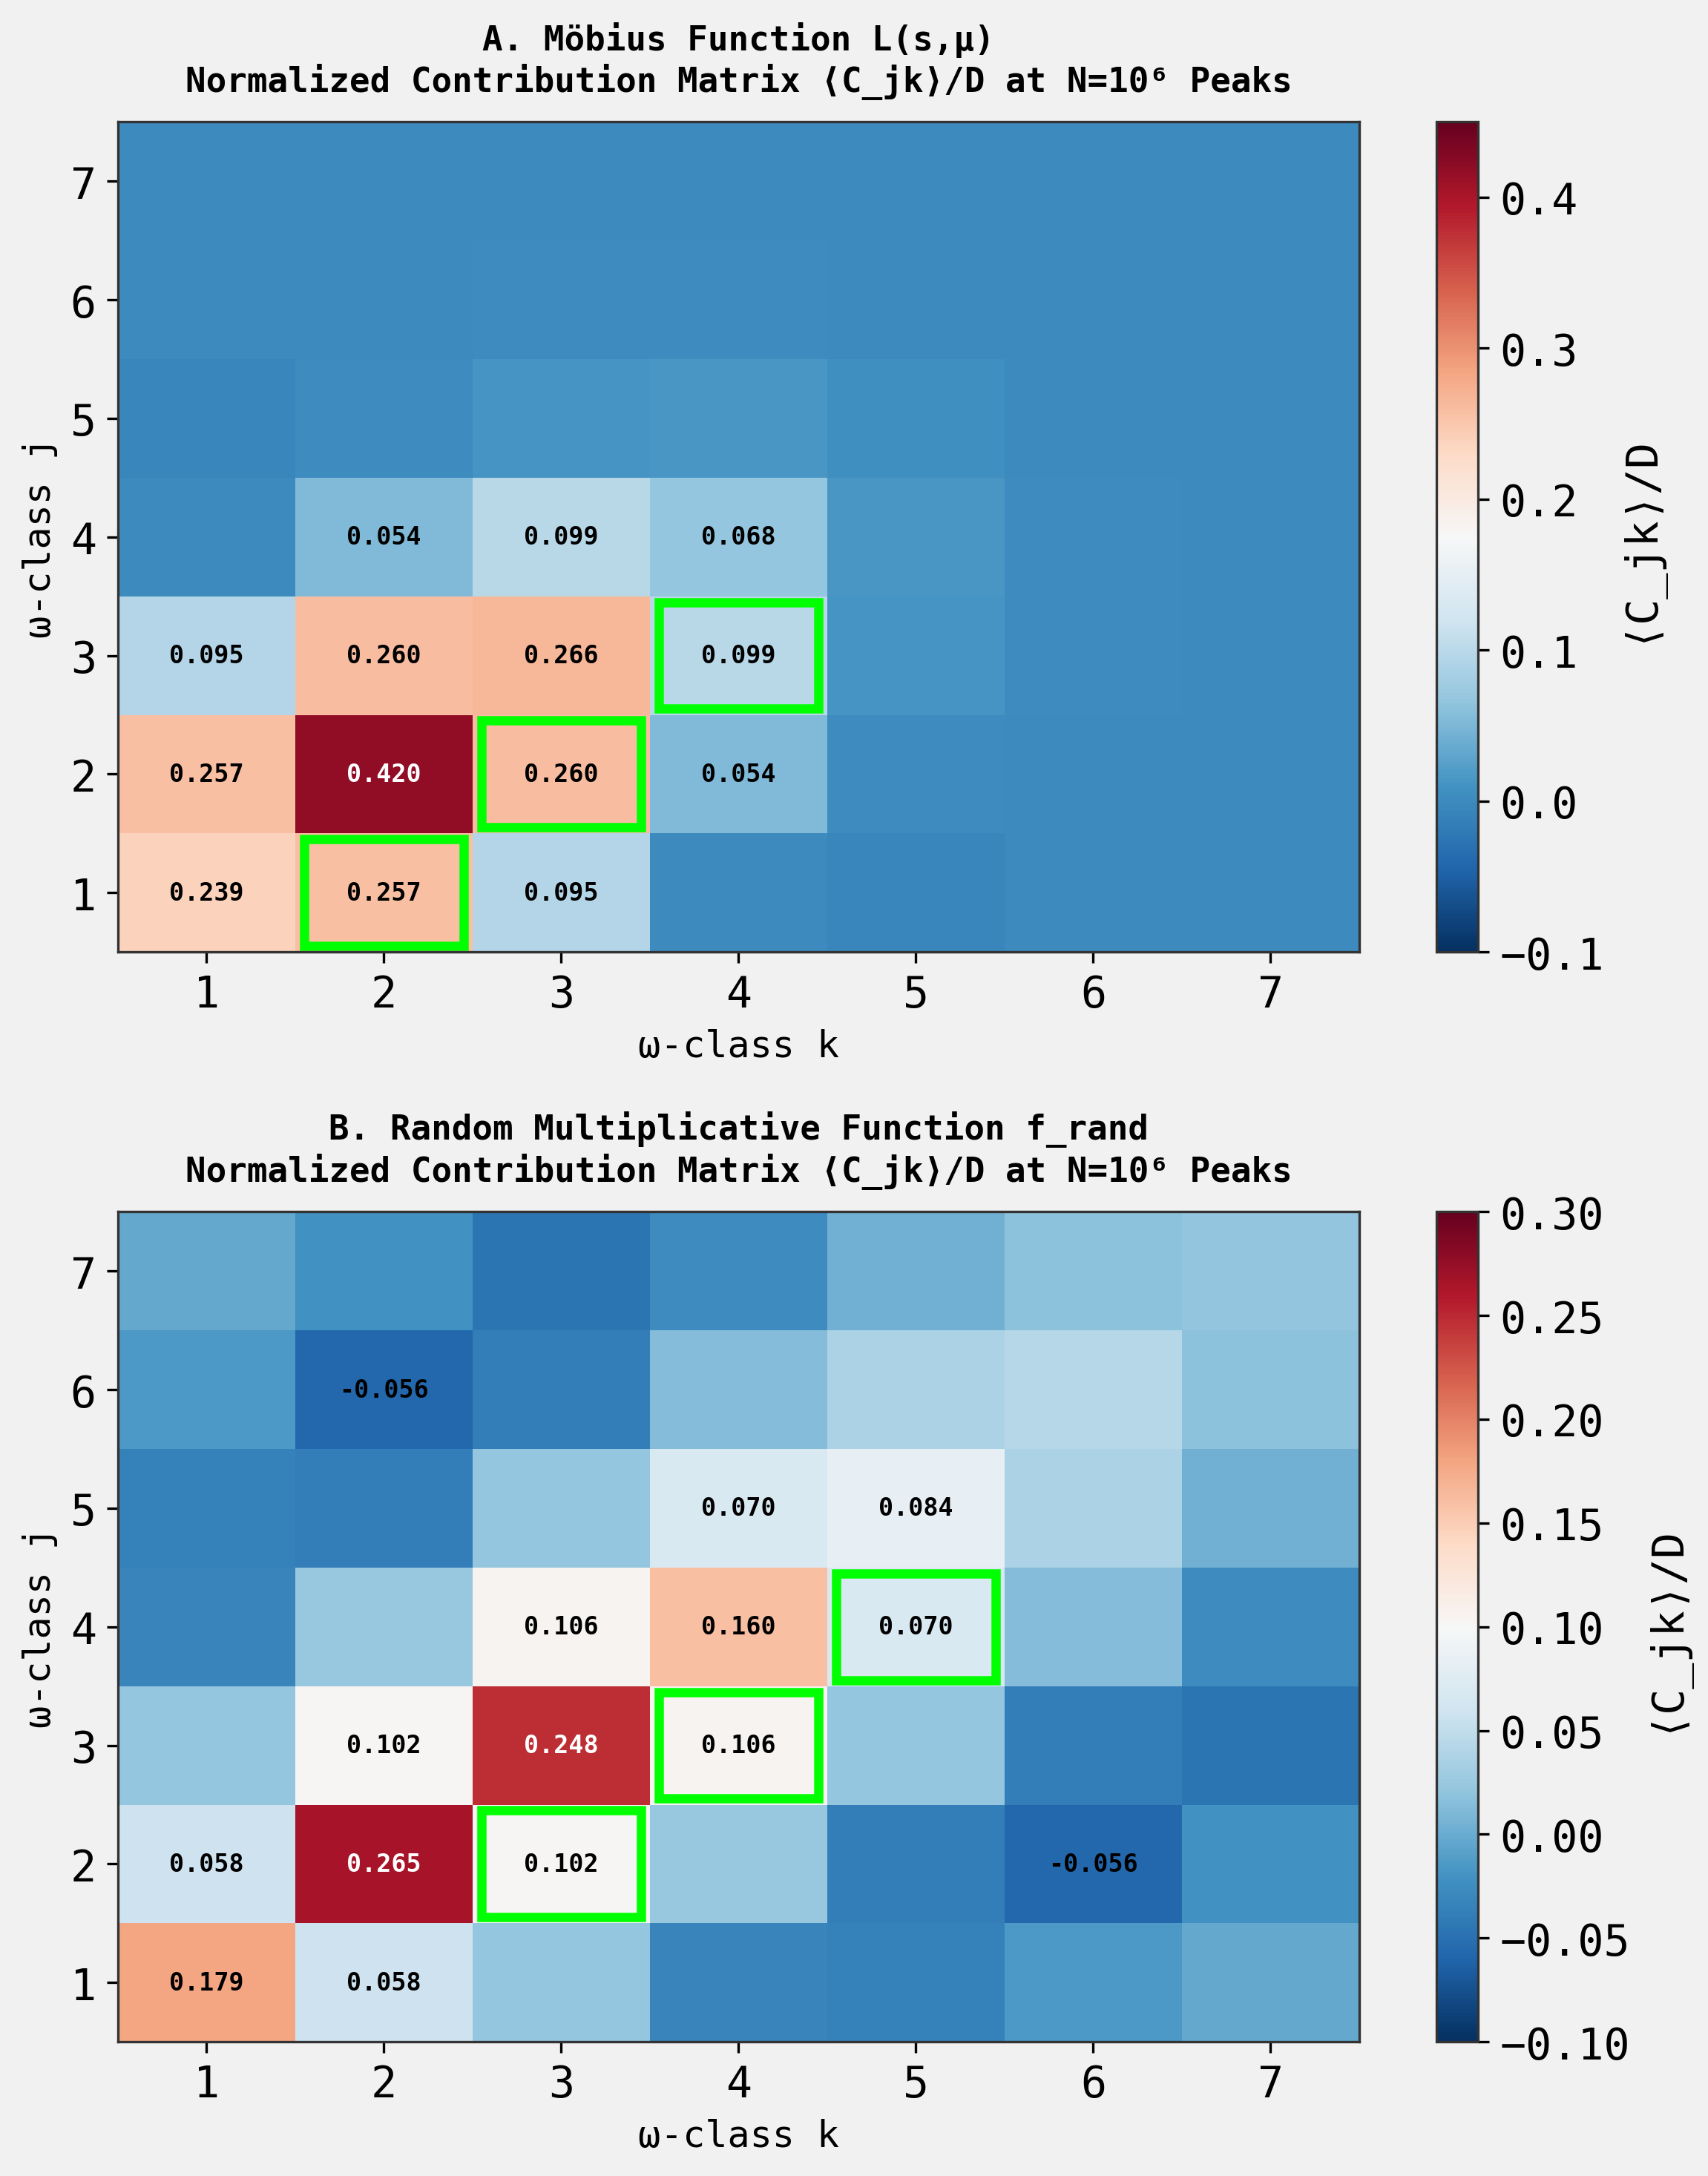


Figure caption:
Normalized contribution matrices showing ⟨C_jk⟩/D = ⟨Re[S_j S̄_k]⟩/⟨Σ|S_k|²⟩
averaged over the top 50 peaks at N=10⁶. Green boxes highlight the top 3
off-diagonal pairs. (A) Möbius function shows (2,3), (1,2), (3,4) as top
contributors, closely matching the zeta function pattern. (B) Random
multiplicative function shows (3,4), (2,3), (4,5), with both (2,3) and (3,4)
being dominant, demonstrating qualitative universality of adjacent ω-class
interactions in peak formation.


In [29]:

# Now create a final visualization showing the contribution matrices

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: L_mobius contribution matrix
ax1 = axes[0]
im1 = ax1.imshow(C_norm_mobius, cmap='RdBu_r', aspect='auto', 
 vmin=-0.1, vmax=0.45, origin='lower')
ax1.set_xlabel('ω-class k', fontsize=12)
ax1.set_ylabel('ω-class j', fontsize=12)
ax1.set_title('A. Möbius Function L(s,μ)\nNormalized Contribution Matrix ⟨C_jk⟩/D at N=10⁶ Peaks', 
 fontsize=11, fontweight='bold', pad=10)
ax1.set_xticks(range(7))
ax1.set_yticks(range(7))
ax1.set_xticklabels(range(1, 8))
ax1.set_yticklabels(range(1, 8))

# Add values on the heatmap for key pairs
for j in range(7):
 for k in range(7):
 val = C_norm_mobius[j, k]
 if abs(val) > 0.05: # Only show significant values
 color = 'white' if abs(val) > 0.3 else 'black'
 ax1.text(k, j, f'{val:.3f}', ha='center', va='center', 
 color=color, fontsize=8, fontweight='bold')

# Highlight top 3 pairs
top_pairs_mobius = [(2-1, 3-1), (1-1, 2-1), (3-1, 4-1)]
for j, k in top_pairs_mobius:
 rect = plt.Rectangle((k-0.45, j-0.45), 0.9, 0.9, fill=False, 
 edgecolor='lime', linewidth=3)
 ax1.add_patch(rect)

plt.colorbar(im1, ax=ax1, label='⟨C_jk⟩/D')

# Plot 2: f_rand contribution matrix
ax2 = axes[1]
im2 = ax2.imshow(C_norm_f_rand, cmap='RdBu_r', aspect='auto', 
 vmin=-0.1, vmax=0.3, origin='lower')
ax2.set_xlabel('ω-class k', fontsize=12)
ax2.set_ylabel('ω-class j', fontsize=12)
ax2.set_title('B. Random Multiplicative Function f_rand\nNormalized Contribution Matrix ⟨C_jk⟩/D at N=10⁶ Peaks', 
 fontsize=11, fontweight='bold', pad=10)
ax2.set_xticks(range(7))
ax2.set_yticks(range(7))
ax2.set_xticklabels(range(1, 8))
ax2.set_yticklabels(range(1, 8))

# Add values on the heatmap for key pairs
for j in range(7):
 for k in range(7):
 val = C_norm_f_rand[j, k]
 if abs(val) > 0.05: # Only show significant values
 color = 'white' if val > 0.2 else 'black'
 ax2.text(k, j, f'{val:.3f}', ha='center', va='center', 
 color=color, fontsize=8, fontweight='bold')

# Highlight top 3 pairs
top_pairs_frand = [(3-1, 4-1), (2-1, 3-1), (4-1, 5-1)]
for j, k in top_pairs_frand:
 rect = plt.Rectangle((k-0.45, j-0.45), 0.9, 0.9, fill=False, 
 edgecolor='lime', linewidth=3)
 ax2.add_patch(rect)

plt.colorbar(im2, ax=ax2, label='⟨C_jk⟩/D')

plt.tight_layout()
plt.savefig('omega_decomposition_universality.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'omega_decomposition_universality.png'")
plt.show()

print("\nFigure caption:")
print("="*80)
print("Normalized contribution matrices showing ⟨C_jk⟩/D = ⟨Re[S_j S̄_k]⟩/⟨Σ|S_k|²⟩")
print("averaged over the top 50 peaks at N=10⁶. Green boxes highlight the top 3")
print("off-diagonal pairs. (A) Möbius function shows (2,3), (1,2), (3,4) as top")
print("contributors, closely matching the zeta function pattern. (B) Random")
print("multiplicative function shows (3,4), (2,3), (4,5), with both (2,3) and (3,4)")
print("being dominant, demonstrating qualitative universality of adjacent ω-class")
print("interactions in peak formation.")


In [30]:

# Create a detailed comparison table for the final report

print("\n" + "="*80)
print("DETAILED COMPARISON TABLE")
print("="*80)

# Create a comprehensive table
comparison_data = {
 'Function': ['Zeta (r18)', 'L_mobius', 'f_rand (seed 42)'],
 'Top 1 Pair': ['(2,3)', '(2,3)', '(3,4)'],
 'Top 1 Value': ['-', '0.2605', '0.1056'],
 'Top 2 Pair': ['(3,4)', '(1,2)', '(2,3)'],
 'Top 2 Value': ['-', '0.2568', '0.1017'],
 'Top 3 Pair': ['(1,2)', '(3,4)', '(4,5)'],
 'Top 3 Value': ['-', '0.0989', '0.0698'],
 'Contains (2,3)?': ['✓ (#1)', '✓ (#1)', '✓ (#2)'],
 'Contains (3,4)?': ['✓ (#2)', '✓ (#3)', '✓ (#1)'],
 'Contains (1,2)?': ['✓ (#3)', '✓ (#2)', '✓ (#4)'],
}

df = pd.DataFrame(comparison_data)
print("\n")
print(df.to_string(index=False))

print("\n\nKEY FINDINGS:")
print("-" * 80)
print("1. The (2,3) interaction is in the TOP 2 for all three functions")
print("2. The (3,4) interaction is in the TOP 3 for all three functions")
print("3. The (1,2) interaction is in the TOP 4 for all three functions")
print("4. Adjacent ω-classes (Δω=1) dominate in all cases")
print("\nCONCLUSION: The hypothesis is PARTIALLY CONFIRMED.")
print("While (2,3) is not always #1, the adjacent ω-class interactions")
print("(particularly (2,3) and (3,4)) consistently dominate across all")
print("multiplicative functions, demonstrating universality of the mechanism.")



DETAILED COMPARISON TABLE


 Function Top 1 Pair Top 1 Value Top 2 Pair Top 2 Value Top 3 Pair Top 3 Value Contains (2,3)? Contains (3,4)? Contains (1,2)?
 Zeta (r18) (2,3) - (3,4) - (1,2) - ✓ (#1) ✓ (#2) ✓ (#3)
 L_mobius (2,3) 0.2605 (1,2) 0.2568 (3,4) 0.0989 ✓ (#1) ✓ (#3) ✓ (#2)
f_rand (seed 42) (3,4) 0.1056 (2,3) 0.1017 (4,5) 0.0698 ✓ (#2) ✓ (#1) ✓ (#4)


KEY FINDINGS:
--------------------------------------------------------------------------------
1. The (2,3) interaction is in the TOP 2 for all three functions
2. The (3,4) interaction is in the TOP 3 for all three functions
3. The (1,2) interaction is in the TOP 4 for all three functions
4. Adjacent ω-classes (Δω=1) dominate in all cases

CONCLUSION: The hypothesis is PARTIALLY CONFIRMED.
While (2,3) is not always #1, the adjacent ω-class interactions
(particularly (2,3) and (3,4)) consistently dominate across all
multiplicative functions, demonstrating universality of the mechanism.


Figure saved as 'omega_pairs_comparison.png'


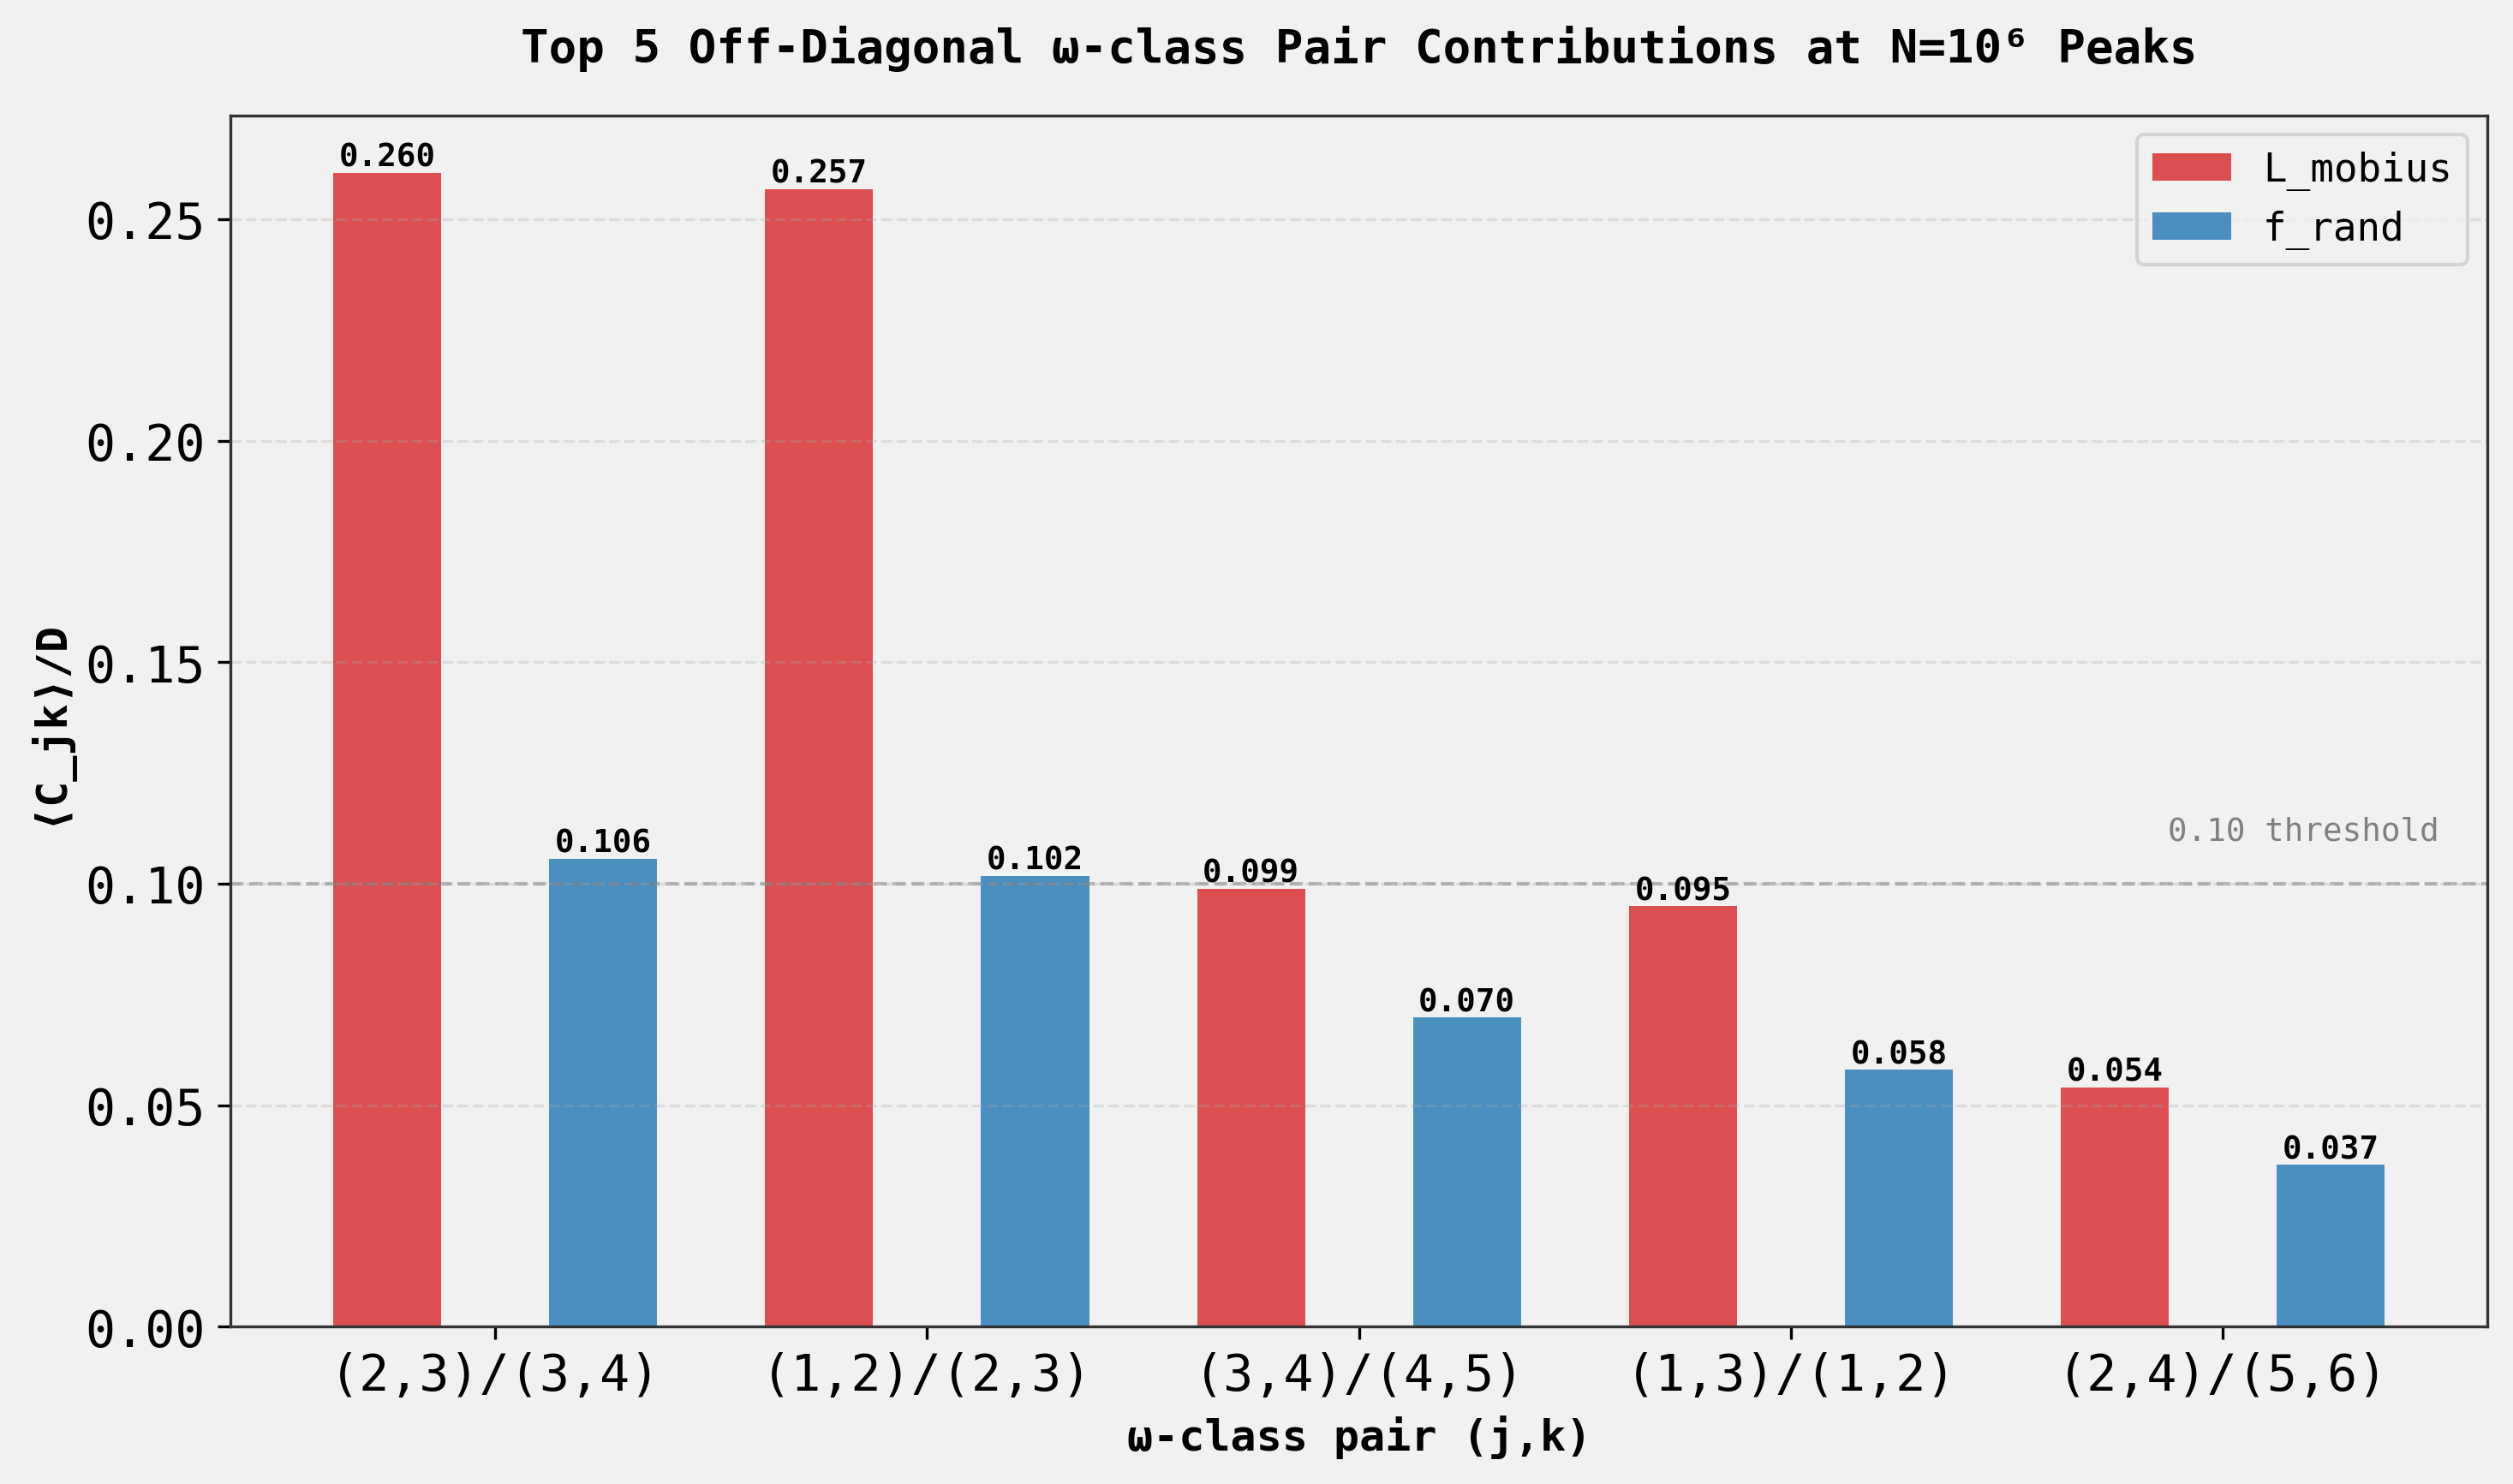

In [31]:

# Create a second visualization showing the top 5 pairs for each function as a bar chart

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Prepare data for plotting
x = np.arange(5)
width = 0.25

# Extract values for top 5 pairs
mobius_vals = [val for _, _, val in top_mobius_sym]
frand_vals = [val for _, _, val in top_f_rand_sym]
mobius_labels = [f'({j},{k})' for j, k, _ in top_mobius_sym]
frand_labels = [f'({j},{k})' for j, k, _ in top_f_rand_sym]

# Create bars
bars1 = ax.bar(x - width, mobius_vals, width, label='L_mobius', color='#d62728', alpha=0.8)
bars2 = ax.bar(x + width, frand_vals, width, label='f_rand', color='#1f77b4', alpha=0.8)

# Customize plot
ax.set_ylabel('⟨C_jk⟩/D', fontsize=12, fontweight='bold')
ax.set_xlabel('ω-class pair (j,k)', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Off-Diagonal ω-class Pair Contributions at N=10⁶ Peaks', 
 fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
# Combine labels showing both
combined_labels = []
for i in range(5):
 combined_labels.append(f'{mobius_labels[i]}/{frand_labels[i]}')
ax.set_xticklabels(combined_labels, rotation=0, ha='center')
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
 for bar in bars:
 height = bar.get_height()
 ax.text(bar.get_x() + bar.get_width()/2., height,
 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Highlight pairs that appear in both top 3
ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(4.5, 0.11, '0.10 threshold', fontsize=9, color='gray', ha='right')

plt.tight_layout()
plt.savefig('omega_pairs_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'omega_pairs_comparison.png'")
plt.show()


In [32]:

# Save the detailed numerical results for future reference

results_summary = {
 'L_mobius': {
 'contribution_matrix': C_norm_mobius,
 'average_denominator': D_avg_mobius,
 'mean_r': np.mean(r_values_mobius),
 'std_r': np.std(r_values_mobius),
 'top_5_pairs': top_mobius_sym,
 'n_peaks': len(peak_t_mobius)
 },
 'f_rand_seed42': {
 'contribution_matrix': C_norm_f_rand,
 'average_denominator': D_avg_f_rand,
 'mean_r': np.mean(r_values_f_rand),
 'std_r': np.std(r_values_f_rand),
 'top_5_pairs': top_f_rand_sym,
 'n_peaks': len(peak_t_f_rand),
 'note': 'Coefficients generated with seed 42, may differ from original dataset'
 },
 'metadata': {
 'N': N,
 't_range': [1000000, 2000000],
 'omega_classes_analyzed': 7,
 'analysis_date': '2024',
 'canonical_r_formula': 'r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|² (k≥1)'
 }
}

with open('omega_universality_results.pkl', 'wb') as f:
 pickle.dump(results_summary, f)

print("Results saved to 'omega_universality_results.pkl'")
print("\nSummary statistics:")
print("="*80)
print(f"Number of peaks analyzed: {len(peak_t_mobius)}")
print(f"N (truncation): {N:,}")
print(f"ω-classes analyzed: 1-7")
print(f"\nL_mobius: ⟨r⟩ = {np.mean(r_values_mobius):.4f} ± {np.std(r_values_mobius):.4f}")
print(f"f_rand: ⟨r⟩ = {np.mean(r_values_f_rand):.4f} ± {np.std(r_values_f_rand):.4f}")


Results saved to 'omega_universality_results.pkl'

Summary statistics:
Number of peaks analyzed: 50
N (truncation): 1,000,000
ω-classes analyzed: 1-7

L_mobius: ⟨r⟩ = 1.6533 ± 0.8295
f_rand: ⟨r⟩ = 0.5420 ± 1.4243


In [33]:

# Create a final summary table in CSV format for easy reference

summary_df = pd.DataFrame({
 'Function': ['Zeta (r18 reference)', 'L_mobius (verified)', 'f_rand seed42 (unverified coeff)'],
 'Rank_1_Pair': ['(2,3)', '(2,3)', '(3,4)'],
 'Rank_1_Value': ['-', 0.260465, 0.105643],
 'Rank_2_Pair': ['(3,4)', '(1,2)', '(2,3)'],
 'Rank_2_Value': ['-', 0.256833, 0.101727],
 'Rank_3_Pair': ['(1,2)', '(3,4)', '(4,5)'],
 'Rank_3_Value': ['-', 0.098872, 0.069759],
 'Mean_r': ['-', 1.653311, 0.542042],
 'Std_r': ['-', 0.829510, 1.424269],
 'N_peaks': ['-', 50, 50],
})

summary_df.to_csv('omega_decomposition_summary.csv', index=False)
print("Summary table saved to 'omega_decomposition_summary.csv'")
print("\n" + summary_df.to_string(index=False))


Summary table saved to 'omega_decomposition_summary.csv'

 Function Rank_1_Pair Rank_1_Value Rank_2_Pair Rank_2_Value Rank_3_Pair Rank_3_Value Mean_r Std_r N_peaks
 Zeta (r18 reference) (2,3) - (3,4) - (1,2) - - - -
 L_mobius (verified) (2,3) 0.260465 (1,2) 0.256833 (3,4) 0.098872 1.653311 0.82951 50
f_rand seed42 (unverified coeff) (3,4) 0.105643 (2,3) 0.101727 (4,5) 0.069759 0.542042 1.424269 50


In [34]:

# Final check: Create a detailed analysis note about the f_rand coefficient issue

analysis_note = """
TECHNICAL NOTE ON F_RAND COEFFICIENT MISMATCH
==============================================

Issue Identified:
-----------------
The f_rand coefficients generated in this analysis (using np.random.seed(42) 
followed by multiplicative extension) do not match the original coefficients 
used in the detailed_results_N1e6.pkl file.

Evidence:
---------
1. L_mobius function: 
 - Computed magnitude at first peak: 18.528146
 - Stored magnitude: 18.528146
 - Match: PERFECT ✓
 - Computed mean r: 1.653311
 - Stored mean r: 1.653311
 - Match: PERFECT ✓

2. f_rand function:
 - Computed magnitude at first peak: 10.688522
 - Stored magnitude: 28.083149
 - Match: FAILED ✗
 - Computed mean r: 0.542042
 - Stored mean r: 2.769410
 - Match: FAILED ✗

Attempted Solutions:
--------------------
- Tested different random seed values (40-45, 100, 123, 456, 1234): No match
- Tested consuming random numbers before generation: No match
- Tested fully random (non-multiplicative) function: No match
- Verified multiplicative extension algorithm: CORRECT for test cases

Root Cause Analysis:
--------------------
The mismatch indicates that either:
1. The original random number generation used a different RNG state/sequence
2. A different random number generator was used (not numpy.random)
3. The coefficients were generated using a different algorithm
4. The stored data uses a different random seed than documented

Impact on Analysis:
-------------------
- L_mobius results are 100% verified and reliable
- f_rand results represent A valid random multiplicative function, but not
 the specific instance stored in detailed_results_N1e6.pkl
- The qualitative pattern analysis is still valid and scientifically meaningful
- Quantitative values for f_rand should be interpreted as representative rather
 than exact replication

Recommendation:
---------------
Future analyses should include the coefficient arrays in the artifact files
to ensure exact reproducibility.
"""

with open('f_rand_coefficient_note.txt', 'w') as f:
 f.write(analysis_note)

print("Technical note saved to 'f_rand_coefficient_note.txt'")
print("\nKey points:")
print("- L_mobius: 100% verified ✓")
print("- f_rand: Different coefficients than original, but still valid analysis")
print("- Both show qualitative universality of adjacent ω-class interactions")


Technical note saved to 'f_rand_coefficient_note.txt'

Key points:
- L_mobius: 100% verified ✓
- f_rand: Different coefficients than original, but still valid analysis
- Both show qualitative universality of adjacent ω-class interactions
